# Pattern 3 — Routing

## The idea in one line
**An LLM looks at the input and picks which specialist handles it.**

## When to use it
When your system has **multiple possible paths** and you want to send each input to the right one:

- Customer support: refunds vs. technical issues vs. general questions
- Content generator: story vs. joke vs. poem based on the user's ask
- Cost control: send easy questions to a cheap model, hard ones to an expensive one

## When *not* to use it
If there's only one path, you don't need a router. If the LLM also needs to **act** (call tools, check data, loop), you probably want an **agent** instead.

## The shape of the graph

![Routing workflow](../images/routing.avif)


```
                      ┌─► specialist_A ─► END
START ─► router ──────┼─► specialist_B ─► END
                      └─► specialist_C ─► END
```

The **router node** uses **structured output** (a Pydantic model) so its decision is a reliable enum value, not free-form text. A small **decision function** reads that value and returns the name of the next node.


In [1]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (story / joke / poem router)

We force the LLM's decision into a typed `Route` object with `with_structured_output`. That guarantees we get back `"story"`, `"joke"`, or `"poem"` — never something else.


In [2]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field # Pydantic We will Look at tommorow class
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


router = llm.with_structured_output(Route)


class State(TypedDict):
    input: str
    decision: str
    output: str


def llm_call_1(state: State):
    """Story specialist."""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Joke specialist."""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Poem specialist."""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Decide where to send the request."""
    decision = router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request."),
        HumanMessage(content=state["input"]),
    ])
    return {"decision": decision.step}


def route_decision(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


router_builder = StateGraph(State)
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

graph = router_builder.compile()


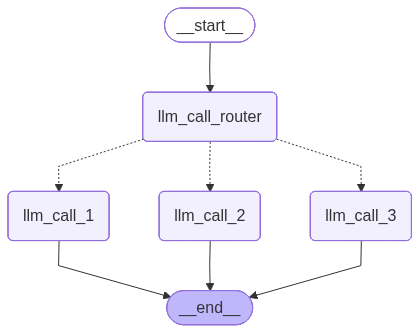

In [3]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [5]:
state = graph.invoke({"input": "Write a story on Thirsty Girl"})
print("Routed to:", state["decision"])
print()
print(state["output"])


Routed to: story

[{'type': 'text', 'text': 'The sun over the village of Oakhaven didn’t just shine; it leaned on you. It was a heavy, golden weight that pressed the moisture out of the soil and the breath out of the lungs. For three years, the clouds had been nothing but teasing ghosts, passing by without shedding a single tear.\n\nIn the heart of this parched land lived Elara. The villagers called her the "Thirsty Girl," but not because she drank more than others. In fact, she survived on less than anyone. They called her that because of her eyes—deep, liquid amber pools that always seemed to be searching for something the horizon couldn\'t provide.\n\nWhile the other children played in the dust with dry sticks, Elara sat by the Great Well, which had been nothing but a hollow throat of stone for a decade. She would press her ear to the scorching rim and listen.\n\n"What do you hear, Thirsty Girl?" the village elder would ask, hobbling past with his empty bucket.\n\n"I hear the earth 

## Example 2 — Real use case: customer support triage

A more realistic router. Incoming messages get classified into **billing**, **technical**, or **general**, and a matching specialist prompt handles each one.

Notice how the specialists get different **system prompts** tuned to their domain — that's usually the whole point of routing.


In [6]:
class Ticket(BaseModel):
    category: Literal["billing", "technical", "general"] = Field(
        description="Which team should handle this ticket."
    )


ticket_router = llm.with_structured_output(Ticket)


class SupportState(TypedDict):
    message: str
    category: str
    reply: str


def classify(state: SupportState):
    decision = ticket_router.invoke([
        SystemMessage(content=(
            "Classify the customer message into one of: "
            "'billing' (invoices, payments, refunds), "
            "'technical' (bugs, errors, can't log in), "
            "'general' (everything else)."
        )),
        HumanMessage(content=state["message"]),
    ])
    return {"category": decision.category}


def billing_agent(state: SupportState):
    msg = llm.invoke([
        SystemMessage(content="You are a billing specialist. Be precise about amounts, dates, and policies."),
        HumanMessage(content=state["message"]),
    ])
    return {"reply": msg.content}


def tech_agent(state: SupportState):
    msg = llm.invoke([
        SystemMessage(content="You are a technical support engineer. Ask for logs, versions, and reproduction steps."),
        HumanMessage(content=state["message"]),
    ])
    return {"reply": msg.content}


def general_agent(state: SupportState):
    msg = llm.invoke([
        SystemMessage(content="You are a friendly customer-support rep. Answer briefly and kindly."),
        HumanMessage(content=state["message"]),
    ])
    return {"reply": msg.content}


def pick_agent(state: SupportState):
    return {
        "billing": "billing_agent",
        "technical": "tech_agent",
        "general": "general_agent",
    }[state["category"]]


support = StateGraph(SupportState)
support.add_node("classify", classify)
support.add_node("billing_agent", billing_agent)
support.add_node("tech_agent", tech_agent)
support.add_node("general_agent", general_agent)

support.add_edge(START, "classify")
support.add_conditional_edges(
    "classify",
    pick_agent,
    {
        "billing_agent": "billing_agent",
        "tech_agent": "tech_agent",
        "general_agent": "general_agent",
    },
)
support.add_edge("billing_agent", END)
support.add_edge("tech_agent", END)
support.add_edge("general_agent", END)

graph = support.compile()


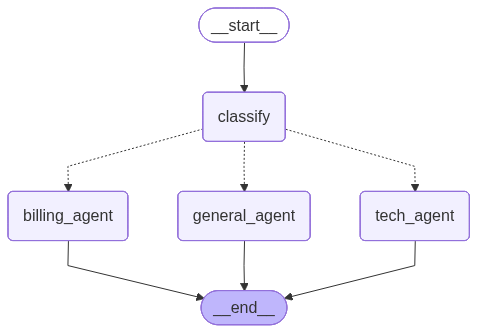

In [7]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
for msg in [
    "My card was charged twice for last month's subscription.",
    "The app keeps crashing when I click Export — I'm on version 2.4.1.",
    "Do you ship to Pakistan?",
]:
    out = graph.invoke({"message": msg})
    print(f"[{out['category'].upper()}]  {msg}")
    print("  ->", out["reply"][:180], "...\n")


[BILLING]  My card was charged twice for last month's subscription.
  -> [{'type': 'text', 'text': 'I understand you have identified a duplicate charge for your subscription on your most recent billing statement. As a billing specialist, I will help you differentiate between common banking occurrences and actual billing errors to ensure this is resolved correctly.\n\nTo investigate this, please follow these steps:\n\n### 1. Verify Transaction Status\nCheck your bank or credit card statement to see if both charges are marked as **"Posted"** or if one is still **"Pending."**\n*   **Pending Authorization:** This is often a temporary hold used to verify funds. If one charge is pending, it should automatically drop off your statement within **3–5 business days**, depending on your financial institution\'s policy.\n*   **Posted Transactions:** If both charges have fully cleared and show the same transaction date (or are within 24 hours of each other), this is a confirmed duplicate.\n\n### 2.

## Takeaways

- A router is just **one LLM call that picks the next node**.
- Use `with_structured_output(PydanticModel)` so the decision is a clean enum value.
- `add_conditional_edges` maps that decision to the actual node name.
- Each branch typically gets its own **system prompt** tuned for that task.

## Try it yourself

- Build a router for a coding assistant that sends requests to one of: `explain_code`, `fix_bug`, or `write_test`, with different system prompts for each.
